In [7]:
import os
import shutil
import random
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras.layers import Dropout


# Augment Images

In [28]:
datagen = ImageDataGenerator(
    rotation_range=60,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=[0.8, 1.2],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    brightness_range=[0.5, 1.0])

def augment_images_in_folder(root_path):
    for folder in os.listdir(root_path):
        folder_path = os.path.join(root_path, folder)
        if os.path.isdir(folder_path):
            images = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
            last_image_num = len(images)  
            for img_name in images:
                img_path = os.path.join(folder_path, img_name)
                img = load_img(img_path) 
                img_array = img_to_array(img)  
                img_array = np.expand_dims(img_array, axis=0)  
                i = 0
                for batch in datagen.flow(img_array, batch_size=1, save_to_dir=folder_path, save_prefix=f'augmented_{folder}', save_format='jpg'):
                    i += 1
                    if i > 20:  # 20 photos per image
                        break
                    last_image_num += 1

root_path = "C:/Users/Chris/ai_cooker/downloaded_images"
augment_images_in_folder(root_path)


In [29]:
def count_files_in_folder(root_folder):
    total_files = 0
    for root, dirs, files in os.walk(root_folder):
        image_files = [f for f in files if f.endswith(('.jpg'))]
        total_files += len(image_files)
    
    return total_files

root_folder = 'C:/Users/Chris/ai_cooker/downloaded_images'
total_images = count_files_in_folder(root_folder)
print(f"Total number of images in {root_folder}: {total_images}")

Total number of images in C:/Users/Chris/ai_cooker/downloaded_images: 43050


# Split into Train/Valid/Test with same Class ratio

In [30]:
def split_dataset_class_wise(original_dataset_dir, output_dir, train_split=0.7, val_split=0.15, test_split=0.15):

    assert train_split + val_split + test_split == 1.0, "Splits must add up to 1.0"

    # Create directories for train, validate, and test sets
    train_dir = os.path.join(output_dir, 'train')
    val_dir = os.path.join(output_dir, 'validate')
    test_dir = os.path.join(output_dir, 'test')

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    # Iterate through each ingredient folder
    for ingredient in os.listdir(original_dataset_dir):
        ingredient_path = os.path.join(original_dataset_dir, ingredient)
        
        if os.path.isdir(ingredient_path):
            images = os.listdir(ingredient_path)
            images = [img for img in images if img.endswith(('.jpg'))] 
            
            if len(images) == 0:
                print(f"No images found in {ingredient_path}. Skipping this folder.")
                continue

            print(f"Processing {len(images)} images for ingredient: {ingredient}")
            
            random.shuffle(images)  #ensure randomness

            #Split for the current ingredient
            train_size = int(len(images) * train_split)
            val_size = int(len(images) * val_split)

            train_images = images[:train_size]
            val_images = images[train_size:train_size + val_size]
            test_images = images[train_size + val_size:]

            # Create subdirectories
            os.makedirs(os.path.join(train_dir, ingredient), exist_ok=True)
            os.makedirs(os.path.join(val_dir, ingredient), exist_ok=True)
            os.makedirs(os.path.join(test_dir, ingredient), exist_ok=True)

            # Move the images to the respective folders
            for image in train_images:
                src_path = os.path.join(ingredient_path, image)
                dest_path = os.path.join(train_dir, ingredient, image)
                shutil.copy(src_path, dest_path)
                print(f"Copied {src_path} to {dest_path}")

            for image in val_images:
                src_path = os.path.join(ingredient_path, image)
                dest_path = os.path.join(val_dir, ingredient, image)
                shutil.copy(src_path, dest_path)
                print(f"Copied {src_path} to {dest_path}")

            for image in test_images:
                src_path = os.path.join(ingredient_path, image)
                dest_path = os.path.join(test_dir, ingredient, image)
                shutil.copy(src_path, dest_path)
                print(f"Copied {src_path} to {dest_path}")

    print(f"Data split complete. Check the {output_dir} folder for train/validate/test sets.")

original_dataset_dir = 'C:/Users/Chris/ai_cooker/downloaded_images'  
output_dir = './dataset_split_class' 

split_dataset_class_wise(original_dataset_dir, output_dir)


Processing 431 images for ingredient: Baking powder
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_139.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_139.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\Baking powder_004.jpg to ./dataset_split_class\train\Baking powder\Baking powder_004.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_2706.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_2706.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_5919.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_5919.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_9211.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_9211.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking 

Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_5670.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_5670.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_3380.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_3380.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_5296.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_5296.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_9419.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_9419.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_3999.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_3999.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_9038.jpg to ./d

Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_909.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_909.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_565.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_565.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_2212.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_2212.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_4949.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_4949.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_4793.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_4793.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_7448.jpg to ./datas

Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_5875.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_5875.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_3711.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_3711.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_4208.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_4208.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_1726.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_1726.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_3835.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_3835.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_6305.jpg to ./d

Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_5357.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_5357.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_3395.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_3395.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_5748.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_5748.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_9294.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_9294.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_647.jpg to ./dataset_split_class\train\Baking powder\augmented_Baking powder_0_647.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Baking powder\augmented_Baking powder_0_6604.jpg to ./dat

...

Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_5491.jpg to ./dataset_split_class\train\Whole wheat bread\augmented_Whole wheat bread_0_5491.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_5176.jpg to ./dataset_split_class\train\Whole wheat bread\augmented_Whole wheat bread_0_5176.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_9098.jpg to ./dataset_split_class\train\Whole wheat bread\augmented_Whole wheat bread_0_9098.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\Whole wheat bread_017.jpg to ./dataset_split_class\train\Whole wheat bread\Whole wheat bread_017.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_7115.jpg to ./dataset_split_class\train\Whole wheat bread\augmented_Whole wheat bread_0_7115.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\W

Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_3914.jpg to ./dataset_split_class\train\Whole wheat bread\augmented_Whole wheat bread_0_3914.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_8767.jpg to ./dataset_split_class\train\Whole wheat bread\augmented_Whole wheat bread_0_8767.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_7458.jpg to ./dataset_split_class\train\Whole wheat bread\augmented_Whole wheat bread_0_7458.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_9555.jpg to ./dataset_split_class\train\Whole wheat bread\augmented_Whole wheat bread_0_9555.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_5950.jpg to ./dataset_split_class\train\Whole wheat bread\augmented_Whole wheat bread_0_5950.jpg
Copied C:/Users/Chris/ai_

Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_5871.jpg to ./dataset_split_class\train\Whole wheat bread\augmented_Whole wheat bread_0_5871.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_2233.jpg to ./dataset_split_class\train\Whole wheat bread\augmented_Whole wheat bread_0_2233.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_7781.jpg to ./dataset_split_class\train\Whole wheat bread\augmented_Whole wheat bread_0_7781.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_966.jpg to ./dataset_split_class\train\Whole wheat bread\augmented_Whole wheat bread_0_966.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_2812.jpg to ./dataset_split_class\train\Whole wheat bread\augmented_Whole wheat bread_0_2812.jpg
Copied C:/Users/Chris/ai_co

Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_3982.jpg to ./dataset_split_class\validate\Whole wheat bread\augmented_Whole wheat bread_0_3982.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_9831.jpg to ./dataset_split_class\validate\Whole wheat bread\augmented_Whole wheat bread_0_9831.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_7126.jpg to ./dataset_split_class\validate\Whole wheat bread\augmented_Whole wheat bread_0_7126.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_3016.jpg to ./dataset_split_class\validate\Whole wheat bread\augmented_Whole wheat bread_0_3016.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_6475.jpg to ./dataset_split_class\validate\Whole wheat bread\augmented_Whole wheat bread_0_6475.jpg
Copied C:/

Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_2869.jpg to ./dataset_split_class\test\Whole wheat bread\augmented_Whole wheat bread_0_2869.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_3514.jpg to ./dataset_split_class\test\Whole wheat bread\augmented_Whole wheat bread_0_3514.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\Whole wheat bread_001.jpg to ./dataset_split_class\test\Whole wheat bread\Whole wheat bread_001.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_1359.jpg to ./dataset_split_class\test\Whole wheat bread\augmented_Whole wheat bread_0_1359.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole wheat bread\augmented_Whole wheat bread_0_6415.jpg to ./dataset_split_class\test\Whole wheat bread\augmented_Whole wheat bread_0_6415.jpg
Copied C:/Users/Chris/ai_cooker/downloaded_images\Whole 

# Naive Accuracy should be 1% given 100 types of ingredients

# Make Benchmark

In [12]:
train_data_dir = 'C:/Users/Chris/ai_cooker/data_collection/dataset_split_class/train'
validation_data_dir = 'C:/Users/Chris/ai_cooker/data_collection/dataset_split_class/validate'
test_data_dir = 'C:/Users/Chris/ai_cooker/data_collection/dataset_split_class/test'

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle = False
)

validation_generator = val_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle = False
)

Found 30093 images belonging to 100 classes.
Found 6403 images belonging to 100 classes.
Found 6554 images belonging to 100 classes.


In [16]:
def flatten_images(generator):
    num_samples = len(generator.filenames)
    flattened_images = np.zeros((num_samples, 150 * 150 * 3))
    labels = np.zeros((num_samples, generator.num_classes))
    
    current_index = 0  # Keep track of the index to store flattened images
    
    for images, labels_batch in generator:
        batch_size = images.shape[0]  # Handle varying batch sizes
        flattened_images[current_index:current_index + batch_size] = images.reshape(batch_size, -1)
        labels[current_index:current_index + batch_size] = labels_batch
        current_index += batch_size  
        
        if current_index >= num_samples:  # Stop if we've processed all images
            break
    
    return flattened_images, labels


In [17]:
X_train, y_train = flatten_images(train_generator)
X_test, y_test = flatten_images(test_generator)

**Too many Features, takes too long**

y_train_indices = np.argmax(y_train, axis=1)
y_test_indices = np.argmax(y_test, axis=1)

log_reg = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial')
log_reg.fit(X_train, y_train_indices)

y_pred = log_reg.predict(X_test)
test_accuracy = accuracy_score(y_test_indices, y_pred)
print(f"Logistic Regression Test Accuracy: {test_accuracy * 100:.2f}%")



print(classification_report(y_test_indices, y_pred))

# Setup from DNN

In [4]:
train_data_dir = 'C:/Users/Chris/ai_cooker/data_collection/dataset_split_class/train'
validation_data_dir = 'C:/Users/Chris/ai_cooker/data_collection/dataset_split_class/validate'
test_data_dir = 'C:/Users/Chris/ai_cooker/data_collection/dataset_split_class/test'

# Create the ImageDataGenerator instances
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create train, validate, and test generators
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Found 30093 images belonging to 100 classes.
Found 6403 images belonging to 100 classes.
Found 6554 images belonging to 100 classes.


# Simple 3 layer network

In [37]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),  
    layers.MaxPooling2D(2, 2), 
    
    layers.Conv2D(64, (3, 3), activation='relu'),  
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Flatten(),  
    layers.Dense(512, activation='relu'),  
    layers.Dense(train_generator.num_classes, activation='softmax')  
])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │      18,940,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,084,964 (72.80 MB)

 Trainable params: 19,084,964 (72.80 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [39]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,  
    epochs=10,  
    validation_data=validation_generator, 
    validation_steps=validation_generator.samples // validation_generator.batch_size  
)


Epoch 1/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 386s 408ms/step - accuracy: 0.0812 - loss: 3.9573 - val_accuracy: 0.2713 - val_loss: 2.6351
Epoch 2/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 0s 42us/step - accuracy: 0.3750 - loss: 2.1745 - val_accuracy: 0.0000e+00 - val_loss: 3.2826
Epoch 3/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 269s 286ms/step - accuracy: 0.3523 - loss: 2.3422 - val_accuracy: 0.3984 - val_loss: 2.0682
Epoch 4/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 0s 25us/step - accuracy: 0.4688 - loss: 2.3478 - val_accuracy: 0.6667 - val_loss: 1.4258
Epoch 5/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 267s 284ms/step - accuracy: 0.5731 - loss: 1.4659 - val_accuracy: 0.4588 - val_loss: 1.9276
Epoch 6/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 0s 25us/step - accuracy: 0.5625 - loss: 1.5074 - val_accuracy: 0.0000e+00 - val_loss: 4.9387
Epoch 7/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 268s 285ms/step - accuracy: 0.7564 - loss: 0.7949 - val_accuracy: 0.4991 - val_loss: 1.9299
Epoch 8/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 0s 26us/step - accuracy: 0.7500 - los

In [40]:
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
model.save('basic_cnn_model.h5')



204/204 ━━━━━━━━━━━━━━━━━━━━ 36s 178ms/step - accuracy: 0.5036 - loss: 2.1784


Test Loss: 2.2388479709625244
Test Accuracy: 0.5003063678741455


3 Layer : 50% Accuracy, 2.239 Loss

# 4 layer network

In [42]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(256, (3, 3), activation='relu'),  # one more layer
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(train_generator.num_classes, activation='softmax')
])
model.summary()
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size, 
    epochs=10,  
    validation_data=validation_generator, 
    validation_steps=validation_generator.samples // validation_generator.batch_size  
)
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)                   │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 15, 15, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 512)                 │       6,423,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,862,756 (26.18 MB)

 Trainable params: 6,862,756 (26.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 231s 244ms/step - accuracy: 0.0488 - loss: 4.1326 - val_accuracy: 0.1617 - val_loss: 3.1616
Epoch 2/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 0s 37us/step - accuracy: 0.0625 - loss: 3.4331 - val_accuracy: 0.3333 - val_loss: 2.5106
Epoch 3/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 226s 240ms/step - accuracy: 0.2401 - loss: 2.7841 - val_accuracy: 0.3262 - val_loss: 2.3837
Epoch 4/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 0s 25us/step - accuracy: 0.2812 - loss: 2.4748 - val_accuracy: 0.3333 - val_loss: 3.7069
Epoch 5/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 224s 238ms/step - accuracy: 0.4176 - loss: 1.9907 - val_accuracy: 0.4538 - val_loss: 1.8538
Epoch 6/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 0s 25us/step - accuracy: 0.5312 - loss: 1.8368 - val_accuracy: 0.6667 - val_loss: 1.4806
Epoch 7/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 223s 237ms/step - accuracy: 0.5764 - loss: 1.3825 - val_accuracy: 0.5427 - val_loss: 1.5165
Epoch 8/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 0s 36us/step - accuracy: 0.6250 - loss: 1.066

In [43]:
model.save('4_layer_cnn_model.h5')

4 Layer: 57.3% Accuracy, 1.46 Loss

# 6 Layer Network


In [8]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(256, (3, 3), activation='relu'),  
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(512, (3, 3), activation='relu'),  
    
    layers.Conv2D(512, (3, 3), activation='relu'),  
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 15, 15, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 5, 5, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 3, 3, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 1, 1, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,242,340 (16.18 MB)

 Trainable params: 4,242,340 (16.18 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [10]:

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,  
    epochs=10, 
    validation_data=validation_generator, 
    validation_steps=validation_generator.samples // validation_generator.batch_size 
)



Epoch 1/10


C:\Users\Chris\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


940/940 ━━━━━━━━━━━━━━━━━━━━ 253s 267ms/step - accuracy: 0.0253 - loss: 4.3370 - val_accuracy: 0.1009 - val_loss: 3.5336
Epoch 2/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 0s 50us/step - accuracy: 0.1250 - loss: 3.8790 - val_accuracy: 0.0000e+00 - val_loss: 3.6372
Epoch 3/10


C:\Users\Chris\anaconda3\Lib\contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


940/940 ━━━━━━━━━━━━━━━━━━━━ 240s 255ms/step - accuracy: 0.1325 - loss: 3.3466 - val_accuracy: 0.1745 - val_loss: 3.0440
Epoch 4/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 0s 29us/step - accuracy: 0.1562 - loss: 3.0635 - val_accuracy: 0.6667 - val_loss: 2.1755
Epoch 5/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 237s 252ms/step - accuracy: 0.2109 - loss: 2.8816 - val_accuracy: 0.2656 - val_loss: 2.6126
Epoch 6/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 0s 28us/step - accuracy: 0.2188 - loss: 2.7291 - val_accuracy: 0.0000e+00 - val_loss: 4.9314
Epoch 7/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 240s 255ms/step - accuracy: 0.2863 - loss: 2.4757 - val_accuracy: 0.3247 - val_loss: 2.3403
Epoch 8/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 0s 30us/step - accuracy: 0.3125 - loss: 2.4716 - val_accuracy: 0.3333 - val_loss: 2.4909
Epoch 9/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 239s 254ms/step - accuracy: 0.3617 - loss: 2.1476 - val_accuracy: 0.3808 - val_loss: 2.0765
Epoch 10/10
940/940 ━━━━━━━━━━━━━━━━━━━━ 0s 29us/step - accuracy: 0.5625 - loss: 1.4739 - va

In [11]:
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")

204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - accuracy: 0.3791 - loss: 2.0665
Test Loss: 2.055314064025879
Test Accuracy: 0.38618260622024536


6 Layer: 38.6% Accuracy, 2.05 Loss

# Introducing Batch Normalization on one layer

In [5]:
model_4_bn = models.Sequential([
    layers.Conv2D(32, (3, 3), input_shape=(150, 150, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    
    layers.Dense(512),
    layers.Activation('relu'),
    

    layers.Dense(100, activation='softmax')
])
model_4_bn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


with 20 epochs

In [7]:
history = model_4_bn.fit(
    train_generator, 
    epochs=10, 
    validation_data=validation_generator
)

Epoch 1/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 442s 470ms/step - accuracy: 0.9005 - loss: 0.3295 - val_accuracy: 0.5540 - val_loss: 2.1204
Epoch 2/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 424s 450ms/step - accuracy: 0.9185 - loss: 0.2642 - val_accuracy: 0.5744 - val_loss: 2.1173
Epoch 3/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 424s 450ms/step - accuracy: 0.9353 - loss: 0.2187 - val_accuracy: 0.5710 - val_loss: 2.2456
Epoch 4/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 424s 450ms/step - accuracy: 0.9415 - loss: 0.1909 - val_accuracy: 0.5690 - val_loss: 2.2568
Epoch 5/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 423s 450ms/step - accuracy: 0.9504 - loss: 0.1703 - val_accuracy: 0.5437 - val_loss: 2.6556
Epoch 6/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 432s 459ms/step - accuracy: 0.9451 - loss: 0.1814 - val_accuracy: 0.5854 - val_loss: 2.1982
Epoch 7/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 437s 464ms/step - accuracy: 0.9619 - loss: 0.1260 - val_accuracy: 0.4829 - val_loss: 3.3387
Epoch 8/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 428s 455ms/step - accuracy: 0.9606 -

In [8]:
test_loss, test_acc = model_4_bn.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")

204/204 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - accuracy: 0.5825 - loss: 2.4161
Test Loss: 2.362687587738037
Test Accuracy: 0.5834864974021912


# Looks like Overfitting may be occuring, high validation accuracy but low test accuracy

4 Layer + 1 Layer with Batch Normaltion, 
58.35% Accuracy, 2.36 Loss

# 4 layer Batch Norm

In [5]:
model_4_bn4 = models.Sequential([
    layers.Conv2D(32, (3, 3), input_shape=(150, 150, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    
    layers.Dense(512),
    layers.Activation('relu'),
    

    layers.Dense(100, activation='softmax')
])
model_4_bn4.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [6]:
history = model_4_bn4.fit(
    train_generator, 
    epochs=10, 
    validation_data=validation_generator
)

Epoch 1/10


C:\Users\Chris\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 11/941 ━━━━━━━━━━━━━━━━━━━━ 8:58 579ms/step - accuracy: 0.0163 - loss: 22.3059

KeyboardInterrupt: 

In [ ]:
test_loss, test_acc = model_4_bn.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")

4 Layer + 4 Layer with Batch Normaltion, 
58.35% Accuracy, 2.37 Loss

# It seems that additional Batch Normalization did not do much, but it does have slight increase in accuracy options:
 - Try different learning rates,
 - Add some dropout, for overfitting
 - try BN in different layers
 - early stoppage for overfitting

 **Benchmark: 4 Layer, 57% accuracy, 1.46 Loss**

1. Adding Dropout after dense layer

In [18]:
model_4_bn = models.Sequential([
    layers.Conv2D(32, (3, 3), input_shape=(150, 150, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    
    layers.Dense(512),
    layers.Activation('relu'),    

    layers.Dense(100, activation='softmax')
])
model_4_bn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model_4_bn.fit(
    train_generator, 
    epochs=10, 
    validation_data=validation_generator
)
test_loss, test_acc = model_4_bn.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")


Epoch 1/10


C:\Users\Chris\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


104/941 ━━━━━━━━━━━━━━━━━━━━ 6:07 439ms/step - accuracy: 0.0095 - loss: 4.8211

KeyboardInterrupt: 

Check Confusion matrix, to see where errors might nbe occuring

205/205 ━━━━━━━━━━━━━━━━━━━━ 17s 80ms/step


<Axes: >

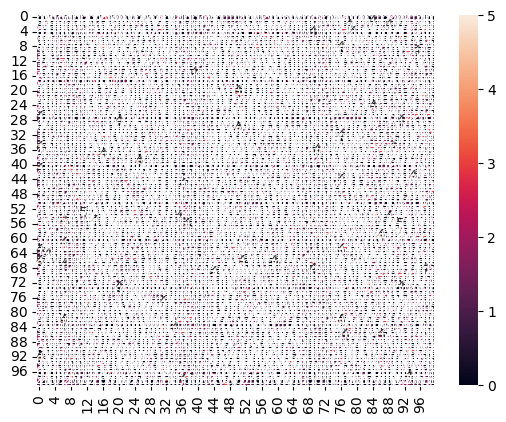

In [14]:
y_pred = model_4_bn.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(test_generator.classes, y_pred_classes)
sns.heatmap(cm, annot=True)

In [15]:
model_4_bn.save('model_4_bn.h5') 

In [ ]:
model_4_bnD = models.Sequential([
    layers.Conv2D(32, (3, 3), input_shape=(150, 150, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    
    layers.Dense(512),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    

    layers.Dense(100, activation='softmax')
])
model_4_bnD.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model_4_bnD.fit(
    train_generator, 
    epochs=10, 
    validation_data=validation_generator
)
test_loss, test_acc = model_4_bnD.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")


Epoch 1/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 420s 444ms/step - accuracy: 0.0453 - loss: 4.2321 - val_accuracy: 0.1610 - val_loss: 3.2905
Epoch 2/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 428s 454ms/step - accuracy: 0.1892 - loss: 3.0905 - val_accuracy: 0.2881 - val_loss: 2.5657
Epoch 3/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 438s 465ms/step - accuracy: 0.3129 - loss: 2.4699 - val_accuracy: 0.3705 - val_loss: 2.1911
Epoch 4/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 435s 462ms/step - accuracy: 0.4395 - loss: 1.9568 - val_accuracy: 0.4549 - val_loss: 1.8854
Epoch 5/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 430s 457ms/step - accuracy: 0.5373 - loss: 1.5549 - val_accuracy: 0.4692 - val_loss: 1.8235
Epoch 6/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 431s 458ms/step - accuracy: 0.6205 - loss: 1.2470 - val_accuracy: 0.5605 - val_loss: 1.4834
Epoch 7/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 437s 465ms/step - accuracy: 0.6882 - loss: 1.0277 - val_accuracy: 0.5302 - val_loss: 1.7297
Epoch 8/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 433s 460ms/step - accuracy: 0.7388 -